In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("pima-indians-diabetes.csv")

In [3]:
df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [4]:
#Incorporating column headers
df.columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"]

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
#Checking for NaNs
pd.isna(np.nan)

True

In [8]:
#Convert all zeros to NaNs
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns] = df[columns].replace(0, np.nan)

In [9]:
df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     373
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,767.000000,762.000000,732.000000,540.000000,394.000000,756.000000,767.000000,767.000000,767.000000
mean,3.842243,121.652231,72.405738,29.142593,155.548223,32.455952,0.471674,33.219035,0.348110
std,3.370877,30.540786,12.390616,10.483667,118.775855,6.929448,0.331497,11.752296,0.476682
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.371000,29.000000,0.000000
75%,6.000000,140.750000,80.000000,36.000000,190.000000,36.600000,0.625000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
#Comparing mean and median
df.mean(), df.median()

(Pregnancies                   3.842243
 Glucose                     121.652231
 BloodPressure                72.405738
 SkinThickness                29.142593
 Insulin                     155.548223
 BMI                          32.455952
 DiabetesPedigreeFunction      0.471674
 Age                          33.219035
 Outcome                       0.348110
 dtype: float64,
 Pregnancies                   3.000
 Glucose                     117.000
 BloodPressure                72.000
 SkinThickness                29.000
 Insulin                     125.000
 BMI                          32.300
 DiabetesPedigreeFunction      0.371
 Age                          29.000
 Outcome                       0.000
 dtype: float64)

In [12]:
#Checking skewness
df.skew()

Pregnancies                 0.903976
Glucose                     0.533978
BloodPressure               0.133928
SkinThickness               0.693369
Insulin                     2.166464
BMI                         0.594261
DiabetesPedigreeFunction    1.921190
Age                         1.135165
Outcome                     0.638949
dtype: float64

In [13]:
#Checking kurtosis
df.kurtosis()

Pregnancies                 0.161293
Glucose                    -0.273588
BloodPressure               0.905812
SkinThickness               2.934129
Insulin                     6.370522
BMI                         0.859077
DiabetesPedigreeFunction    5.593374
Age                         0.660872
Outcome                    -1.595913
dtype: float64

<Axes: ylabel='Frequency'>

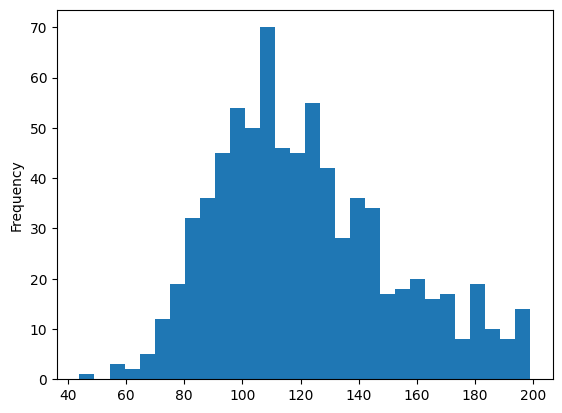

In [14]:
#Plotting each histogram for better analysis
df["Glucose"].plot(kind="hist", bins=30)

<Axes: ylabel='Frequency'>

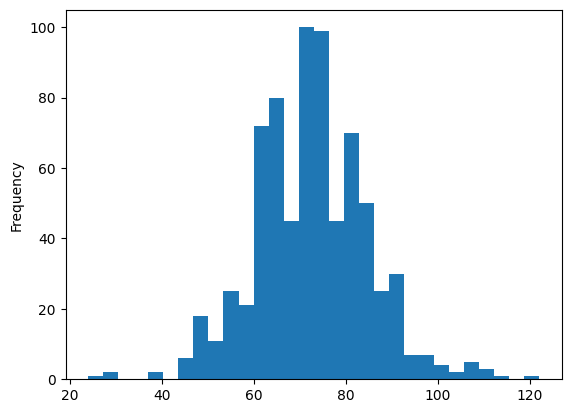

In [15]:
df["BloodPressure"].plot(kind="hist", bins=30)

<Axes: ylabel='Frequency'>

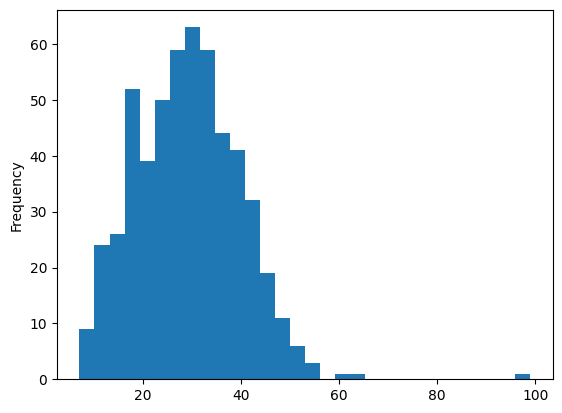

In [16]:
df["SkinThickness"].plot(kind="hist", bins=30)

<Axes: ylabel='Frequency'>

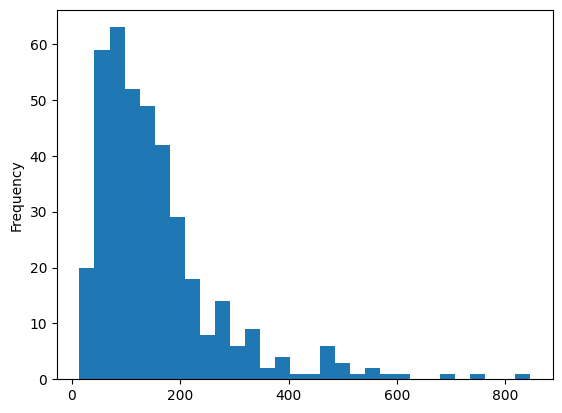

In [17]:
df["Insulin"].plot(kind="hist", bins=30)

<Axes: ylabel='Frequency'>

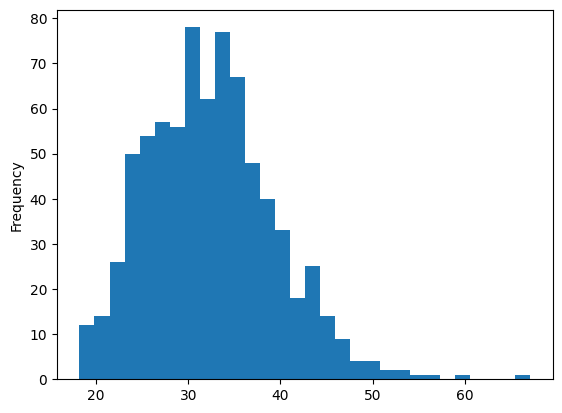

In [18]:
df["BMI"].plot(kind="hist", bins=30)

In [19]:
#Splitting training data
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [20]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [21]:
median = X_train[columns].median()
X_train[columns] = X_train[columns].fillna(median)
X_val[columns] = X_val[columns].fillna(median)

In [22]:
X_train.isna().sum(), X_val.isna().sum()

(Pregnancies                 0
 Glucose                     0
 BloodPressure               0
 SkinThickness               0
 Insulin                     0
 BMI                         0
 DiabetesPedigreeFunction    0
 Age                         0
 dtype: int64,
 Pregnancies                 0
 Glucose                     0
 BloodPressure               0
 SkinThickness               0
 Insulin                     0
 BMI                         0
 DiabetesPedigreeFunction    0
 Age                         0
 dtype: int64)

In [23]:
#Normalize data
scaler = StandardScaler()

In [24]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [26]:
#Train model
model = GaussianNB(var_smoothing=1e-8)

In [27]:
model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-08


In [28]:
y_pred = model.predict(X_val_scaled)

In [29]:
#Evaluate model
accuracy = accuracy_score(y_val, y_pred)
print(accuracy)

0.6688311688311688


In [30]:
#Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

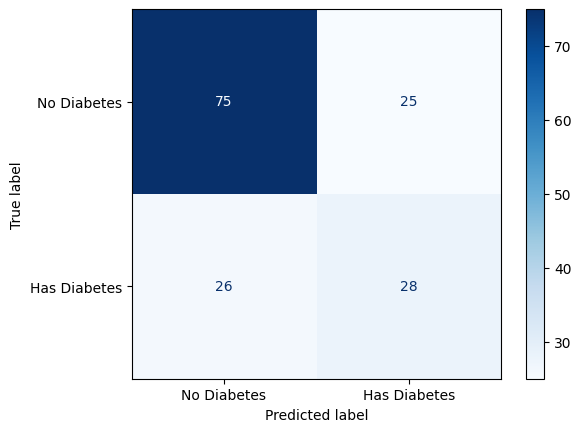

In [31]:
display = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels = ["No Diabetes", "Has Diabetes"])
display.plot(cmap="Blues")

In [32]:
#Calculate score for ROC_AUC using probabilities
y_probs = model.predict_proba(X_val_scaled)[:, 1]

In [33]:
roc_auc = roc_auc_score(y_val, y_probs)

In [34]:
print(roc_auc)

0.7292592592592593


In [35]:
#Calculating f1 score
f1 = f1_score(y_val, y_pred)

In [36]:
print(f1)

0.5233644859813084


In [43]:
#Benchmark with Logistic Regression
log_model = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", class_weight="balanced", max_iter=1000)

In [44]:
log_model.fit(X_train_scaled, y_train)

C:\Users\fayed\myprojects\ml4job\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [49]:
log_y_pred = log_model.predict(X_val_scaled)

In [50]:
#Evaluate Logistics Regression model
log_accuracy = accuracy_score(y_val, log_y_pred)
print(log_accuracy)

0.7077922077922078


In [51]:
log_f1 = f1_score(y_val, log_y_pred)
print(log_f1)

0.6017699115044248


In [52]:
log_y_probs = model.predict_proba(X_val_scaled)[:, 1]
log_roc_auc = roc_auc_score(y_val, log_y_probs)

In [53]:
print(log_roc_auc)

0.7292592592592593


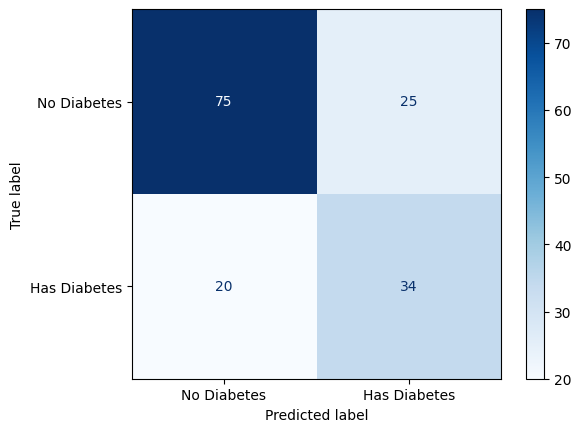

In [54]:
#Confusion Matrix
cm_log = confusion_matrix(y_val, log_y_pred)
log_display = ConfusionMatrixDisplay(confusion_matrix=cm_log,
                                 display_labels = ["No Diabetes", "Has Diabetes"])
log_display.plot(cmap="Blues")